<a href="https://colab.research.google.com/github/SonalShukla-projects/Bankruptcy_Prediction_Company_ML_Project/blob/main/notebooks/07_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

XG Boost Model

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/ML_DATASETS/clean_bankruptcy_data.csv"
df=pd.read_csv(path)

In [4]:
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

0.9655425219941349 0.5769230769230769 0.29411764705882354 0.38961038961038963


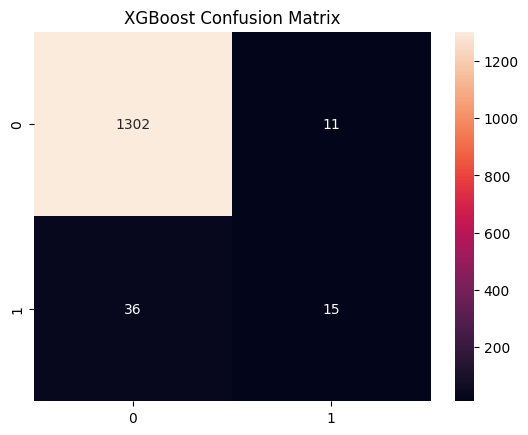

In [5]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print(accuracy,precision,recall,f1)

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.show()

results = pd.DataFrame({
    "Model":["XGBoost"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1":[f1]
})
import os

base_path = "/content/drive/MyDrive/ML_Project_Results"
os.makedirs(base_path, exist_ok=True)

results.to_csv(f"{base_path}/xgboost_results.csv", index=False)

In [6]:
# 70:30 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("XGBoost 70:30")
print(accuracy, precision, recall, f1)

results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Split": ["70:30"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1]
})
results.to_csv(f"{base_path}/xgboost_70_30.csv", index=False)

XGBoost 70:30
0.9623655913978495 0.5161290322580645 0.20512820512820512 0.29357798165137616
